In [1]:
import pandas as pd

df = pd.read_parquet("../dataset/Benign-Monday-no-metadata.parquet")

df.head()

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,6,4,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1,6,1,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
2,6,3,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
3,6,1,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
4,6,609,7,4,484,414,233,0,69.14286,111.967896,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign


In [2]:
df.shape

(458831, 78)

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Protocol,458831.0,1.103306e+01,5.486413e+00,0.0,6.0,6.0,17.0,17.0
Flow Duration,458831.0,1.196980e+07,3.056838e+07,-1.0,281.0,50968.0,1311110.0,119999987.0
Total Fwd Packets,458831.0,1.171436e+01,9.590487e+02,1.0,2.0,2.0,6.0,219759.0
Total Backward Packets,458831.0,1.319606e+01,1.260931e+03,0.0,1.0,2.0,4.0,291922.0
Fwd Packets Length Total,458831.0,6.082904e+02,6.690243e+03,0.0,43.0,74.0,392.0,1323378.0
...,...,...,...,...,...,...,...,...
Active Min,458831.0,5.059022e+04,5.363391e+05,0.0,0.0,0.0,0.0,101659665.0
Idle Mean,458831.0,3.999468e+06,1.385968e+07,0.0,0.0,0.0,0.0,119999736.0
Idle Std,458831.0,2.338050e+05,2.330636e+06,0.0,0.0,0.0,0.0,75145024.0
Idle Max,458831.0,4.180491e+06,1.432384e+07,0.0,0.0,0.0,0.0,119999735.0


In [4]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

Series([], dtype: int64)

In [8]:

print("Duplicate Records :", df.duplicated().sum())
df.dtypes.value_counts()


Duplicate Records : 0


int32       27
float32     22
int8        20
int16        6
float64      2
category     1
Name: count, dtype: int64

In [9]:
df["Label"].value_counts()

Label
Benign    458831
Name: count, dtype: int64

In [10]:
(df["Label"].value_counts(normalize=True)*100).round(2)

Label
Benign    100.0
Name: proportion, dtype: float64

Matplotlib is building the font cache; this may take a moment.


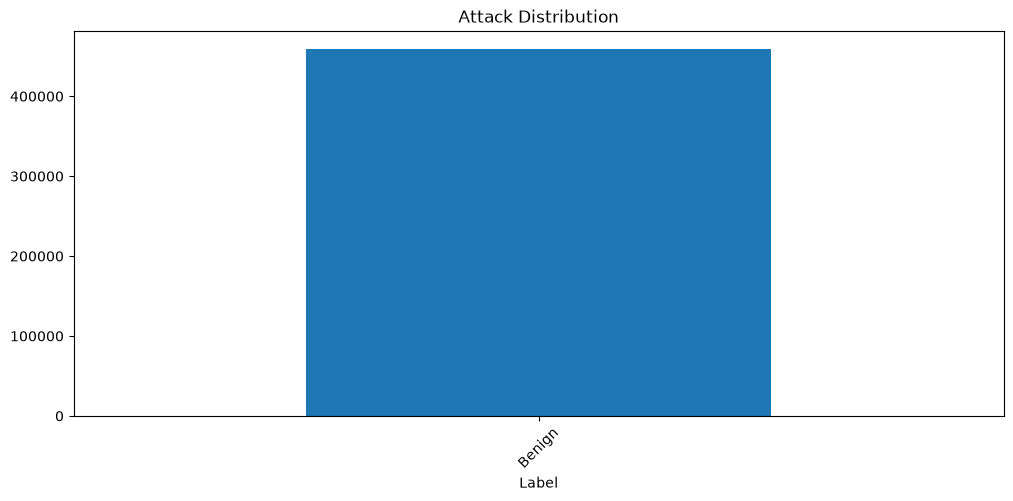

In [11]:
import matplotlib.pyplot as plt

df["Label"].value_counts().plot(
    kind="bar",
    figsize=(12,5),
    title="Attack Distribution"
)

plt.xticks(rotation=45)
plt.show()

In [12]:
import os

for file in os.listdir("../dataset"):
    print(file)

DDoS-Friday-no-metadata.parquet
Bruteforce-Tuesday-no-metadata.parquet
Botnet-Friday-no-metadata.parquet
DoS-Wednesday-no-metadata.parquet
Benign-Monday-no-metadata.parquet
Infiltration-Thursday-no-metadata.parquet
Portscan-Friday-no-metadata.parquet
WebAttacks-Thursday-no-metadata.parquet


In [13]:
import pandas as pd
import glob
import os
files = glob.glob("../dataset/*.parquet")

print(f"Total Files: {len(files)}")

for file in files:
    print(os.path.basename(file))

files = glob.glob("../dataset/*.parquet")

print(f"Total Files: {len(files)}")

for file in files:
    print(os.path.basename(file))


Total Files: 8
DDoS-Friday-no-metadata.parquet
Bruteforce-Tuesday-no-metadata.parquet
Botnet-Friday-no-metadata.parquet
DoS-Wednesday-no-metadata.parquet
Benign-Monday-no-metadata.parquet
Infiltration-Thursday-no-metadata.parquet
Portscan-Friday-no-metadata.parquet
WebAttacks-Thursday-no-metadata.parquet
Total Files: 8
DDoS-Friday-no-metadata.parquet
Bruteforce-Tuesday-no-metadata.parquet
Botnet-Friday-no-metadata.parquet
DoS-Wednesday-no-metadata.parquet
Benign-Monday-no-metadata.parquet
Infiltration-Thursday-no-metadata.parquet
Portscan-Friday-no-metadata.parquet
WebAttacks-Thursday-no-metadata.parquet


In [14]:
dataframes = []

for file in files:
    print(f"Loading: {os.path.basename(file)}")
    temp_df = pd.read_parquet(file)
    dataframes.append(temp_df)

Loading: DDoS-Friday-no-metadata.parquet
Loading: Bruteforce-Tuesday-no-metadata.parquet
Loading: Botnet-Friday-no-metadata.parquet
Loading: DoS-Wednesday-no-metadata.parquet
Loading: Benign-Monday-no-metadata.parquet
Loading: Infiltration-Thursday-no-metadata.parquet
Loading: Portscan-Friday-no-metadata.parquet
Loading: WebAttacks-Thursday-no-metadata.parquet


In [15]:
df = pd.concat(dataframes, ignore_index=True)

In [16]:
print(df.shape)

(2313810, 78)


In [17]:
df["Label"].value_counts()

Label
Benign                        1977318
DoS Hulk                       172846
DDoS                           128014
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
PortScan                         1956
Web Attack � Brute Force         1470
Bot                              1437
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

In [18]:
df.to_parquet("../dataset/merged_dataset.parquet", index=False)